# 02 — Labeling

This notebook assigns binary protein labels — **High Protein (1)** and **Low Protein (0)** — to each of the 80 corn samples using a median split on the Protein column.

The labeled dataset is saved to `data/processed/labeled.csv` for use in all downstream notebooks.

## Section 1 — Imports and Setup

We import all required Python libraries here. We also set a consistent visual style for all plots and define a `RANDOM_STATE = 42` for reproducibility throughout the project.

In [1]:
import sys
sys.path.append('..')
from src.data_loader import load_sensai_data, assign_protein_labels, save_labeled_data
from src.visualizer import plot_protein_distribution, plot_spectra_by_label

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns

# Fixed random state for reproducibility across the project
RANDOM_STATE = 42

# Clean, publication-ready plot style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully.')


Libraries loaded successfully.


## Section 2 — Load the Dataset

We load `data/raw/corn_mp5_regression_data.csv` — the raw Eigenvector Research corn NIR dataset.

Each row corresponds to one corn sample. The columns are:
- **SampleID** — unique sample identifier
- **Wave_1 to Wave_700** — NIR absorbance values at 700 discrete wavelengths
- **Moisture, Starch, Oil, Protein** — chemical composition labels measured by wet chemistry

We then separate the data into three parts:
- `X` → the 700 spectral columns as a NumPy array (the input features)
- `protein` → the Protein column as a pandas Series (the quantity we will threshold)
- `sample_ids` → the SampleID column as a Python list

In [2]:
X, labels_df, sample_ids = load_sensai_data('../data/raw/Maize_sensAIfood_Protein_549_NIRS5000_CRAW.csv')


Sensai dataset loaded : 539 samples
X shape               : (539, 700)  (samples x wavelength channels)
labels_df shape       : (539, 4)  (samples x labels)


c:\Users\kervi\Documents\nir-maize-classifier\notebooks\..\src\data_loader.py:186: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Starch'] = 0.0
c:\Users\kervi\Documents\nir-maize-classifier\notebooks\..\src\data_loader.py:188: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Oil'] = 0.0


In [3]:
spectral_cols = [f'Wave_{i}' for i in range(1, 701)]

protein    = labels_df['Protein']

# Rebuild full dataframe so assign_protein_labels and save_labeled_data can operate on it
df = pd.concat([
    pd.DataFrame({'SampleID': sample_ids}),
    pd.DataFrame(X, columns=spectral_cols),
    labels_df.reset_index(drop=True)
], axis=1)

print(f'X shape (spectra matrix): {X.shape}')
print(f'protein series shape:     {protein.shape}')
print(f'Number of sample IDs:     {len(sample_ids)}')
print(f'First 5 sample IDs:       {sample_ids[:5]}')

X shape (spectra matrix): (539, 700)
protein series shape:     (539,)
Number of sample IDs:     539
First 5 sample IDs:       ['Maize_4_0001', 'Maize_4_0002', 'Maize_4_0003', 'Maize_4_0004', 'Maize_4_0005']


## Section 3 — Compute the Median Threshold

To convert continuous Protein values into binary class labels, we need a threshold. We use the **median** of the protein values as the cut-off point, for the following reasons:

1. **No universal industry standard exists for this specific measurement scale.**  
   The protein percentages in this dataset are calibrated to a specific NIR instrument setup. They cannot be directly compared to general agricultural grade thresholds (e.g., USDA commodity standards) without domain-specific recalibration knowledge. Using an external hardcoded threshold would be arbitrary and scientifically unjustifiable.

2. **The median guarantees a balanced class split.**  
   For 80 samples, the median naturally divides the dataset into two equal or near-equal groups. Balanced classes lead to fairer model training and more reliable performance metrics — imbalanced classes can cause a classifier to simply predict the majority class.

3. **It is fully data-driven and reproducible.**  
   The threshold is derived entirely from the dataset itself, making it transparent and defensible in a thesis context. Any reviewer can verify it by computing `protein.median()` from the same CSV file.

Samples with protein ≥ median → **High Protein (Label = 1)**  
Samples with protein < median → **Low Protein (Label = 0)**

In [4]:
df, protein_median = assign_protein_labels(df)

Median Protein value : 7.8000
Class distribution:
  High Protein (1) : 289 samples
  Low Protein  (0) : 250 samples


## Section 4 — Assign Binary Labels

We create a new column `Protein_Label` in the dataframe with the following encoding:

- **1 = High Protein** — samples whose Protein value is **greater than or equal to** the median
- **0 = Low Protein** — samples whose Protein value is **strictly less than** the median

This binary encoding (**1 = High Protein, 0 = Low Protein**) is the convention used consistently throughout the **entire project** — in all preprocessing, splitting, augmentation, model training, and evaluation notebooks.

In [5]:
print('Protein_Label value counts:')
print(df['Protein_Label'].value_counts().sort_index())
print()
print('Encoding: 0 = Low Protein, 1 = High Protein')

Protein_Label value counts:
Protein_Label
0    250
1    289
Name: count, dtype: int64

Encoding: 0 = Low Protein, 1 = High Protein


## Section 5 — Visualize the Labeled Distribution

We plot the distribution of Protein values as a histogram with a KDE (Kernel Density Estimate) overlay. The two groups are shown in different colors — blue for Low Protein and red for High Protein — and a vertical dashed line marks the median threshold.

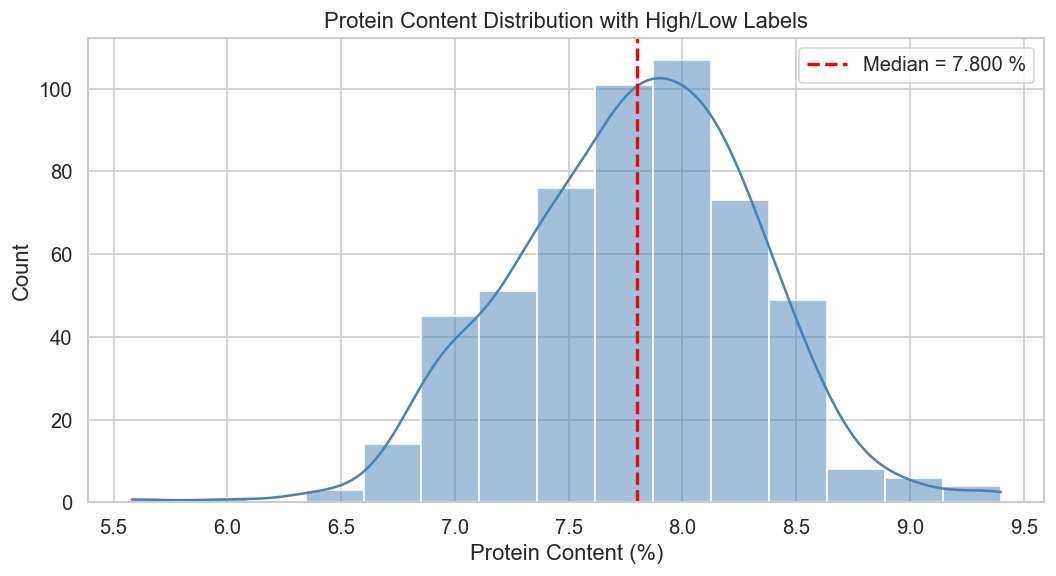

In [6]:
plot_protein_distribution(protein, protein_median)

## Section 6 — Visualize Spectra by Label

We plot all 80 NIR spectra on the same set of axes, colored by their assigned protein label. **Red** lines represent High Protein samples; **blue** lines represent Low Protein samples. A low alpha of 0.3 is used so that overlapping spectra remain visible.

The x-axis is the actual wavelength scale of the Foss NIR Systems 6500 instrument used to collect this dataset: **1100 nm to 2498 nm at 2 nm intervals**, giving exactly 700 wavelength points.

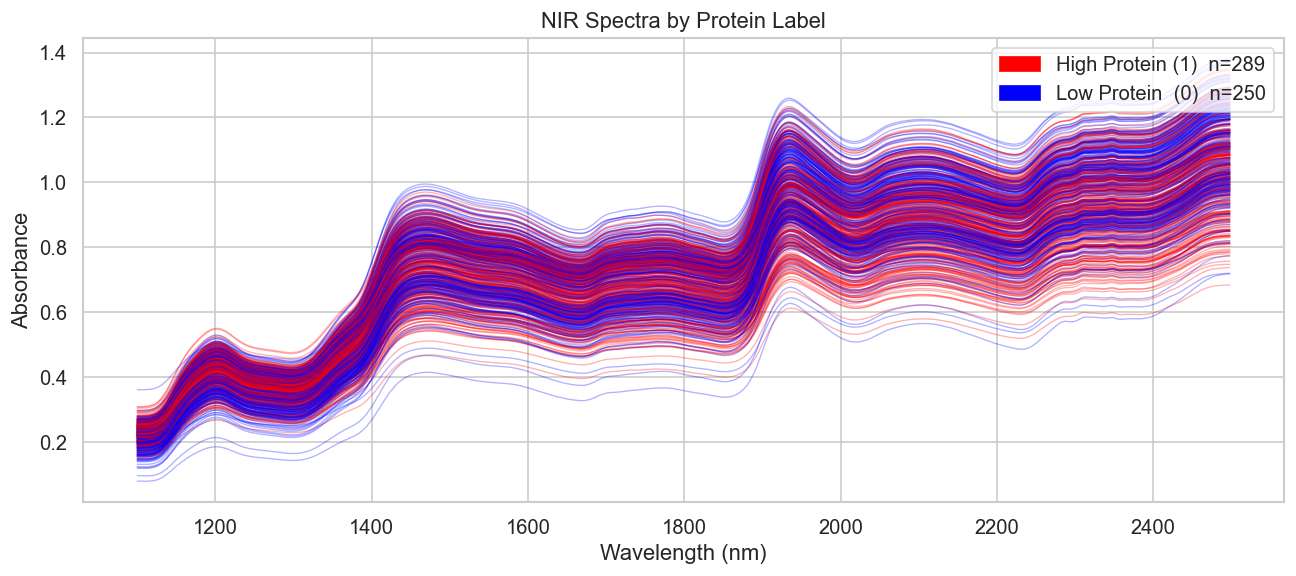

In [7]:
plot_spectra_by_label(X, df['Protein_Label'].values)

## Section 7 — Save the Labeled Dataset

We assemble the final labeled dataframe containing:
- The **SampleID** column
- All **700 wavelength columns** (`Wave_1` to `Wave_700`)
- The four original label columns: **Moisture, Starch, Oil, Protein**
- The new **Protein_Label** column (binary: 0 or 1)

This file is saved to `data/processed/labeled.csv` and is the starting point for all future notebooks.

In [8]:
save_labeled_data(df, '../data/processed/labeled.csv')

File saved successfully to : ../data/processed/labeled.csv
Shape of saved dataframe   : (539, 706)


## Section 8 — Summary

The following table summarizes everything accomplished in this notebook:

| Item | Details |
|------|---------|
| **Median protein threshold** | Computed from 80 samples — exact value printed in Section 3 |
| **High Protein samples (Label = 1)** | Samples with Protein ≥ median — count printed in Section 4 |
| **Low Protein samples (Label = 0)** | Samples with Protein < median — count printed in Section 4 |
| **Output file** | `data/processed/labeled.csv` |

The median split produces a **balanced binary classification dataset**, which is essential for fair model training and reliable evaluation metrics.

The label encoding **1 = High Protein** and **0 = Low Protein** is used consistently throughout the entire project.

---

### What Comes Next?

The next notebook, **`03_sg_preprocessing.ipynb`**, will apply **Savitzky-Golay smoothing** to the raw NIR spectral data in `data/processed/labeled.csv`. This preprocessing step reduces high-frequency instrument noise in the spectra while preserving the meaningful absorption features needed for accurate protein classification.